In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Define a quadratic loss
Function

In [ ]:
def quadratic_loss(x,y):
  return x**2 + 10*y**2

Please not that we are not defining the dataset yet, we are saying somehow we know the equation of loss function is like what we defined and x,y are the parameters


In [ ]:
def quadratic_grad(x,y):
  dx=2*x
  dy=20*y
  return np.array([dx,dy])

Batch Gradient Descent(BGD)

In [ ]:
def batch_gradient_descent(grad_func,eta,epochs,start_point):
  x,y=start_point
  path=[(x,y)]
  losses=[quadratic_loss(x,y)]

  for _ in range(epochs):
    grad=grad_func(x,y)
    x-=eta*grad[0]
    y-=eta*grad[1]
    path.append((x,y))
    losses.append(quadratic_loss(x,y))

  return np.array(path),losses

Gradient Descent with Momentum

In [ ]:
def gradient_descent_momentum(grad_func,eta, beta, epochs, start_point):
  x,y=start_point
  v=np.array([0,0])
  path=[(x,y)]
  losses=[quadratic_loss(x,y)]

  for _ in range(epochs):
    grad=grad_func(x,y)
    v=beta*v+(1-beta)*grad
    x-=eta*v[0]
    y-=eta*v[1]
    path.append((x,y))
    losses.append(quadratic_loss(x,y))

  return np.array(path),losses

Visualization function for paths

In [ ]:
def plot_paths(function,paths,labels,title):
  X,Y=np.meshgrid(np.linspace(-2,2,400), np.linspace(-2,2,400))
  Z=function(X,Y)

  plt.figure(figsize=(8,6))
  plt.contour(X,Y,Z, levels=50, cmap='jet')

  for path, label in zip(paths, labels):
    plt.plot(path[:,0], path[:,1], label=label)
    plt.scatter(path[0,0],path[0,1], color='green', label='Start')
    plt.scatter(path[-1,0],path[-1,-1], color='red', label='End')

  plt.xlabel('x')
  plt.ylabel('y')
  plt.title(title)
  plt.legend()
  plt.savefig('paths2.png')
  plt.show()

Visualization function for losses

In [ ]:
def plot_losses(losses, labels, title):
  plt.figure(figsize=(8,6))

  for loss, label in zip(losses, labels):
    plt.plot(loss, label=label)

  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title(title)
  plt.legend()
  plt.savefig('losses.png')
  plt.show()

Parameters


In [ ]:
eta_bgd=0.1 #Learning rate for BGD
eta_momentum=0.1 #Learning rate for Momentum
beta=0.9 #Momentum coefficient
epochs=50
start_point=(1.5,1.5) #Initial point far from the minimum


Run Optimizations

In [ ]:
from os import path
path_bgd, losses_bgd=batch_gradient_descent(quadratic_grad, eta_bgd, epochs, start_point)
path_momentum, losses_momentum=gradient_descent_momentum(quadratic_grad, eta_momentum, beta, epochs, start_point)

Plot results

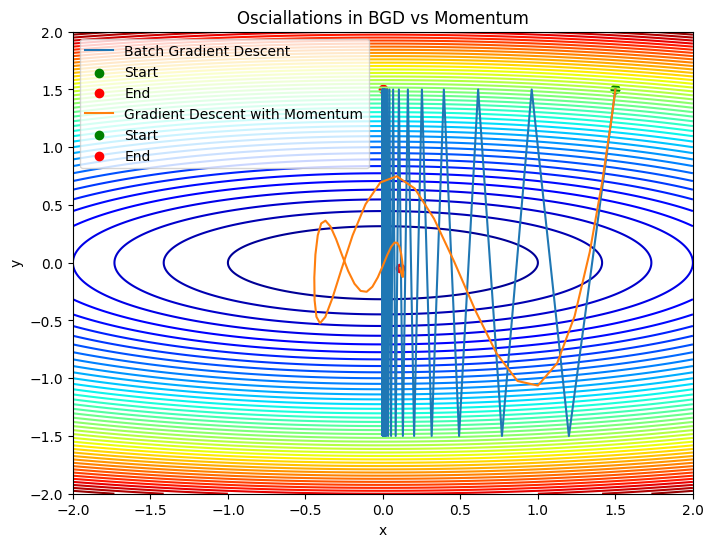

In [ ]:
plot_paths(quadratic_loss,[path_bgd, path_momentum],
           ["Batch Gradient Descent", "Gradient Descent with Momentum"],
           "Osciallations in BGD vs Momentum")

Plot losses

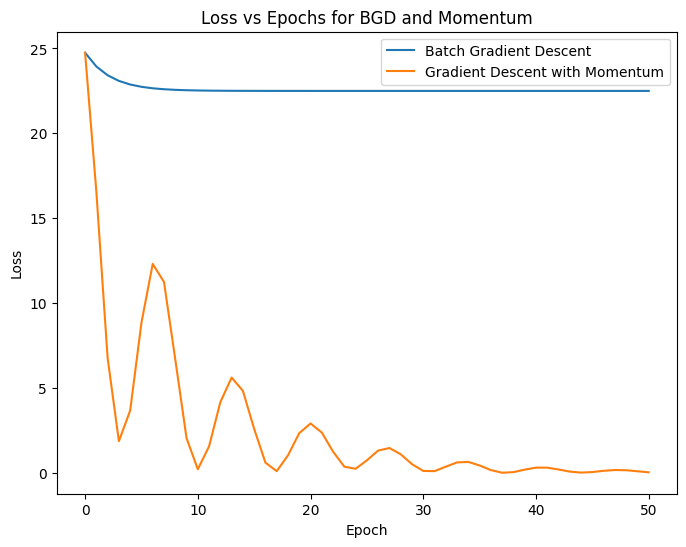

In [ ]:
plot_losses([losses_bgd, losses_momentum],["Batch Gradient Descent", "Gradient Descent with Momentum"],"Loss vs Epochs for BGD and Momentum")